In [36]:
!pip install scikit-surprise

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [63]:
import zipfile
import os
import pandas as pd

# Unzip the Netflix dataset to access movie_titles.csv and combined_data_*.txt
zip_file_path = '/content/sample_data/combined_data_1.txt.zip'
extract_dir = '/content/sample_data/'

# Ensure the directory exists
os.makedirs(extract_dir, exist_ok=True)

# Check if combined_data_1.txt is extracted, if not, extract it
combined_data_file = os.path.join(extract_dir, 'combined_data_1.txt')
if not os.path.exists(combined_data_file):
    print(f"Unzipping {zip_file_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
    # Debugging: list contents to see where files landed
    print(f"Contents of {extract_dir}: {os.listdir(extract_dir)}")
else:
    print(f"{combined_data_file} already extracted.")

# Load movie titles from movie_titles.csv
# movie_titles.csv usually has Movie_ID,Year,Title.
# Adjusting path to look directly in extract_dir based on previous execution output
movie_titles_path = os.path.join(extract_dir, 'movie_titles.csv')
movies = pd.read_csv(
    movie_titles_path,
    encoding='latin1',
    header=None,
    names=['Movie_ID', 'Year', 'Title'],
    on_bad_lines='skip' # Added to handle parsing errors
)

print("Movies Data")
print(movies.head())

/content/sample_data/combined_data_1.txt already extracted.
Movies Data
   Movie_ID    Year                         Title
0         1  2003.0               Dinosaur Planet
1         2  2004.0    Isle of Man TT 2004 Review
2         3  1997.0                     Character
3         4  1994.0  Paula Abdul's Get Up & Dance
4         5  2004.0      The Rise and Fall of ECW


In [52]:
ratings = []
with open('/content/sample_data/combined_data_1.txt', 'r', encoding='latin1') as file:
    current_movie_id = None
    for line in file:
        line = line.strip()
        if line.endswith(':'):
            try:
                current_movie_id = int(line[:-1])
            except ValueError
                current_movie_id = None
        elif current_movie_id is not None:
            parts = line.split(',')
            if len(parts) == 3:
                try:
                    user_id = int(parts[0])
                    rating = int(parts[1])
                    date = parts[2]
                    ratings.append([current_movie_id, user_id, rating, date])
                except ValueError:
                    pass

        if len(ratings) >= 50000:
            print(f"Loaded {len(ratings)} ratings. Stopping to sample data.")
            break

ratings_df = pd.DataFrame(
    ratings,
    columns=['Movie_ID', 'User_ID', 'Rating', 'Date']
)

print("Ratings Data")
print(ratings_df.head())
print(f"Total ratings loaded: {len(ratings_df)}")

Loaded 50000 ratings. Stopping to sample data.
Ratings Data
   Movie_ID  User_ID  Rating        Date
0         1  1488844       3  2005-09-06
1         1   822109       5  2005-05-13
2         1   885013       4  2005-10-19
3         1    30878       4  2005-12-26
4         1   823519       3  2004-05-03
Total ratings loaded: 50000


In [55]:
ratings_df['Movie_ID'] = ratings_df['Movie_ID'].astype(int)
movies['Movie_ID'] = movies['Movie_ID'].astype(int)

df = pd.merge(ratings_df, movies, on='Movie_ID')

print("Merged Data")
print(df.head())
print(f"Total merged ratings: {len(df)}")

Merged Data
   Movie_ID  User_ID  Rating        Date    Year            Title
0         1  1488844       3  2005-09-06  2003.0  Dinosaur Planet
1         1   822109       5  2005-05-13  2003.0  Dinosaur Planet
2         1   885013       4  2005-10-19  2003.0  Dinosaur Planet
3         1    30878       4  2005-12-26  2003.0  Dinosaur Planet
4         1   823519       3  2004-05-03  2003.0  Dinosaur Planet
Total merged ratings: 50000


In [65]:
genre_list = ['Action', 'Comedy', 'Drama', 'Romance', 'Horror', 'Sci-Fi', 'Thriller']

movie_genre_map = {
    movie_id: np.random.choice(genre_list)
    for movie_id in df['Movie_ID'].unique()
}

df['Genre'] = df['Movie_ID'].map(movie_genre_map)

print(df[['Movie_ID', 'Title', 'Genre']].head())
print(f"'Genre' column successfully added to df. Total entries: {len(df)}")

   Movie_ID            Title     Genre
0         1  Dinosaur Planet  Thriller
1         1  Dinosaur Planet  Thriller
2         1  Dinosaur Planet  Thriller
3         1  Dinosaur Planet  Thriller
4         1  Dinosaur Planet  Thriller
'Genre' column successfully added to df. Total entries: 50000


In [66]:
popular_genre = df['Genre'].value_counts()

print("Most Popular Genres")
print(popular_genre)

Most Popular Genres
Genre
Drama       16868
Comedy      14834
Action       7108
Thriller     5915
Romance      2810
Horror       1701
Sci-Fi        764
Name: count, dtype: int64


In [67]:
genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

print("Most Liked Genres")
print(genre_rating)

Most Liked Genres
Genre
Comedy      3.521774
Romance     3.511744
Sci-Fi      3.430628
Thriller    3.362468
Drama       3.241107
Horror      3.011170
Action      2.903208
Name: Rating, dtype: float64


In [68]:
print("Best Rated Genre")
print(genre_rating.head(1))

print("Worst Rated Genre")
print(genre_rating.tail(1))

Best Rated Genre
Genre
Comedy    3.521774
Name: Rating, dtype: float64
Worst Rated Genre
Genre
Action    2.903208
Name: Rating, dtype: float64


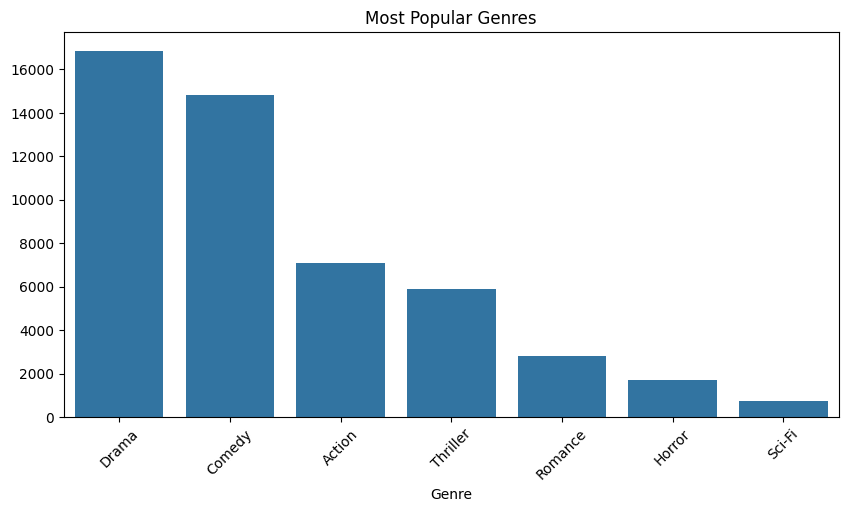

In [69]:
plt.figure(figsize=(10,5))
sns.barplot(x=popular_genre.index, y=popular_genre.values)
plt.title("Most Popular Genres")
plt.xticks(rotation=45)
plt.show()

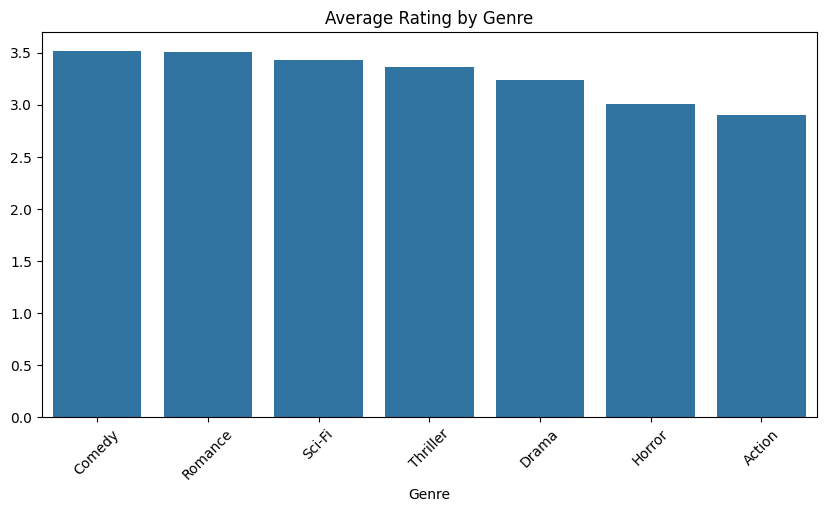

In [70]:
plt.figure(figsize=(10,5))
sns.barplot(x=genre_rating.index, y=genre_rating.values)
plt.title("Average Rating by Genre")
plt.xticks(rotation=45)
plt.show()

In [57]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    df[['User_ID', 'Movie_ID', 'Rating']],
    reader
)


In [58]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [59]:
model = SVD()
model.fit(trainset)


In [60]:
predictions = model.test(testset)
rmse(predictions)


RMSE: 1.1229


1.1229282066179753

In [61]:
user_id = df['User_ID'].iloc[0]

movie_ids = df['Movie_ID'].unique()

recommendations = []

for movie in movie_ids[:100]:
    pred = model.predict(user_id, movie)
    recommendations.append((movie, pred.est))

rec_df = pd.DataFrame(
    recommendations,
    columns=['Movie_ID', 'Predicted_Rating']
)

top_rec = rec_df.sort_values(
    by='Predicted_Rating',
    ascending=False
).head(10)

final_rec = pd.merge(top_rec, movies, on='Movie_ID')

print("Top Recommended Movies for User")
print(final_rec[['Title', 'Predicted_Rating']])

Top Recommended Movies for User
                                               Title  Predicted_Rating
0  Lord of the Rings: The Return of the King: Ext...          4.405625
1                                   Immortal Beloved          4.131480
2                         What the #$*! Do We Know!?          4.028972
3                           The Rise and Fall of ECW          3.958889
4      Inspector Morse 31: Death Is Now My Neighbour          3.599955
5                                  Strange Relations          3.586432
6                                    Dinosaur Planet          3.570305
7  Clifford: Clifford Saves the Day! / Clifford's...          3.547242
8                         Isle of Man TT 2004 Review          3.524229
9                                          Screamers          3.264943


In [73]:
idx = df.groupby('Genre')['Rating'].idxmax()

best_per_genre = df.loc[idx]

print("Best Movie in Every Genre")
print(best_per_genre[['Genre', 'Title', 'Rating']])

Best Movie in Every Genre
          Genre                         Title  Rating
24329    Action                     7 Seconds       5
20010    Comedy      Class of Nuke 'Em High 2       5
2846      Drama      The Rise and Fall of ECW       5
2706     Horror  Paula Abdul's Get Up & Dance       5
550     Romance    Isle of Man TT 2004 Review       5
20551    Sci-Fi          My Favorite Brunette       5
1      Thriller               Dinosaur Planet       5
